# Phase 3: Delivery Delay vs Review Score Analysis

In this notebook, we quantify the impact of operational delays on customer satisfaction by analyzing the relationship between delivery delays and customer review scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Dataset

In [2]:
df = pd.read_csv('../data/processed/merged_olist_data.csv')
print(f"Loaded {df.shape[0]:,} rows.")

Loaded 113,425 rows.


## 2. Prepare Delay Metrics

In [3]:
# Drop rows where delivery date or review score is missing
df_ops = df.dropna(subset=['delivery_delay_days', 'review_score']).copy()

def categorize_delay(days):
    if days <= 0:
        return 'On Time / Early'
    elif days <= 2:
        return '1-2 Days Late'
    elif days <= 5:
        return '3-5 Days Late'
    else:
        return '6+ Days Late'

df_ops['delay_category'] = df_ops['delivery_delay_days'].apply(categorize_delay)
df_ops['delay_category'] = pd.Categorical(df_ops['delay_category'], 
                                          categories=['On Time / Early', '1-2 Days Late', '3-5 Days Late', '6+ Days Late'], 
                                          ordered=True)
df_ops[['delivery_delay_days', 'delay_category', 'review_score']].head()

,delivery_delay_days,delay_category,review_score
0,-7.107488,On Time / Early,4.0
1,-5.355729,On Time / Early,4.0
2,-17.245498,On Time / Early,5.0
3,-12.980069,On Time / Early,5.0
4,-9.238171,On Time / Early,5.0


## 3. Analyze Impact on Review Scores

In [4]:
impact = df_ops.groupby('delay_category').agg({
    'review_score': ['mean', 'count']
}).reset_index()
impact.columns = ['Delay Category', 'Average Review Score', 'Number of Orders']

baseline_score = impact.loc[impact['Delay Category'] == 'On Time / Early', 'Average Review Score'].values[0]
impact['Score Drop vs Baseline'] = impact['Average Review Score'] - baseline_score
impact

,Delay Category,Average Review Score,Number of Orders,Score Drop vs Baseline
0,On Time / Early,4.211098,100849,0.000000
1,1-2 Days Late,3.864020,2368,-0.347078
2,3-5 Days Late,2.766075,1633,-1.445023
3,6+ Days Late,1.778933,4519,-2.432164


## 4. Visualizing the Impact

/var/folders/8x/v6n68_9x62vbkhqycfz1l9bc0000gn/T/ipykernel_13820/3976127975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Delay Category', y='Average Review Score', data=impact, ax=ax1, palette='coolwarm')


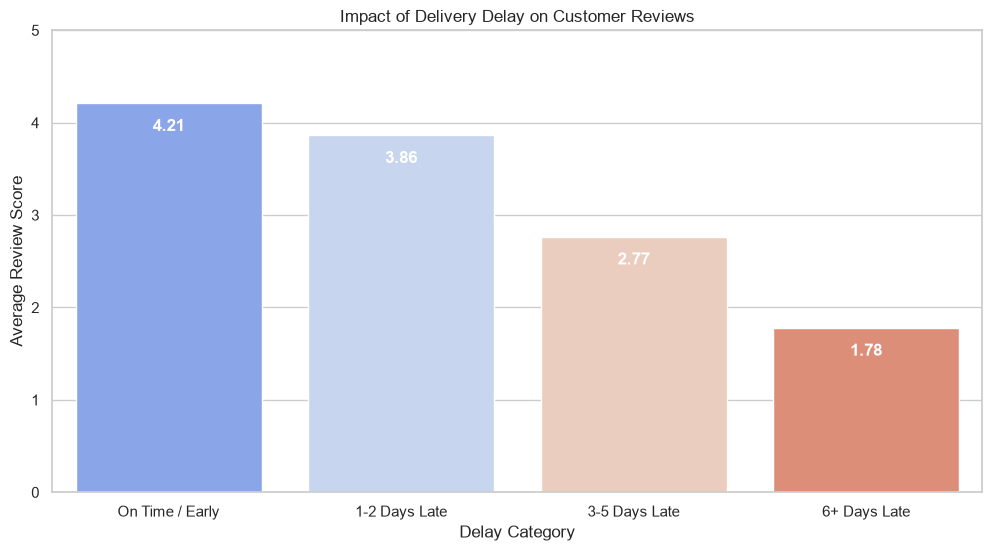

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='Delay Category', y='Average Review Score', data=impact, ax=ax1, palette='coolwarm')
ax1.set_ylim(0, 5)
ax1.set_ylabel('Average Review Score')
ax1.set_title('Impact of Delivery Delay on Customer Reviews')

for i, row in impact.iterrows():
    ax1.text(i, row['Average Review Score'] - 0.3, f"{row['Average Review Score']:.2f}", color='white', ha='center', fontweight='bold')

plt.show()